In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)



In [2]:
data = pd.read_csv('ChronicKidneyDisease.csv')
data.head(5)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
#cek nilai uniq dari kolom pcv
df = ['pcv', 'rc', 'wc', 'dm', 'cad', 'classification']
for r in df:
    print(f'nilai uniq dari kolom {r}: {data[r].unique()}')
    

nilai uniq dari kolom pcv: ['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' nan '16' '24' '37' '30'
 '34' '40' '45' '27' '48' '\t?' '52' '14' '22' '18' '42' '17' '46' '23'
 '19' '25' '41' '26' '15' '21' '43' '20' '\t43' '47' '9' '49' '50' '53'
 '51' '54']
nilai uniq dari kolom rc: ['5.2' nan '3.9' '4.6' '4.4' '5' '4.0' '3.7' '3.8' '3.4' '2.6' '2.8' '4.3'
 '3.2' '3.6' '4' '4.1' '4.9' '2.5' '4.2' '4.5' '3.1' '4.7' '3.5' '6.0'
 '5.0' '2.1' '5.6' '2.3' '2.9' '2.7' '8.0' '3.3' '3.0' '3' '2.4' '4.8'
 '\t?' '5.4' '6.1' '6.2' '6.3' '5.1' '5.8' '5.5' '5.3' '6.4' '5.7' '5.9'
 '6.5']
nilai uniq dari kolom wc: ['7800' '6000' '7500' '6700' '7300' nan '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9800' '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300'
 '7200' '7700' '14600' '6300' '\t6200' '7100' '11800' '9400' '5500' '5800'
 '13200' '12500' '5600' '7000' '11900' '10400' '10700' '12700' '6800'
 '6500' '13600' '10200' '9000

In [4]:
for col in data.select_dtypes(include='object'):
    data[col] = data[col].str.strip()
    print(f'nilai uniq dari kolom {col} setelah di strip: {data[col].unique()}')

nilai uniq dari kolom rbc setelah di strip: [nan 'normal' 'abnormal']
nilai uniq dari kolom pc setelah di strip: ['normal' 'abnormal' nan]
nilai uniq dari kolom pcc setelah di strip: ['notpresent' 'present' nan]
nilai uniq dari kolom ba setelah di strip: ['notpresent' 'present' nan]
nilai uniq dari kolom pcv setelah di strip: ['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' nan '16' '24' '37' '30'
 '34' '40' '45' '27' '48' '?' '52' '14' '22' '18' '42' '17' '46' '23' '19'
 '25' '41' '26' '15' '21' '43' '20' '47' '9' '49' '50' '53' '51' '54']
nilai uniq dari kolom wc setelah di strip: ['7800' '6000' '7500' '6700' '7300' nan '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9800' '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300'
 '7200' '7700' '14600' '6300' '7100' '11800' '9400' '5500' '5800' '13200'
 '12500' '5600' '7000' '11900' '10400' '10700' '12700' '6800' '6500'
 '13600' '10200' '9000' '14900' '8200' '15200' 

In [5]:
#convert kolom pcv, rc, wc ke numeric
for col in ['pcv', 'rc', 'wc']:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data[['pcv', 'rc', 'wc']].dtypes
data.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                71
wc                106
rc                131
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [6]:
#mengolompokkan data berdasarkan klasifikasi
missing_per_class = data.groupby('classification').apply(lambda x: x.isnull().sum())
print(missing_per_class)

                id  age  bp  sg  al  su  rbc  pc  pcc  ba  ...  pcv  wc   rc  \
classification                                             ...                 
ckd              0    8  10  42  41  44  143  56    0   0  ...   67  99  124   
notckd           0    1   2   5   5   5    9   9    4   4  ...    4   7    7   

                htn  dm  cad  appet  pe  ane  classification  
classification                                                
ckd               0   0    0      0   0    0               0  
notckd            2   2    2      1   1    1               0  

[2 rows x 26 columns]


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12616\796890521.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_per_class = data.groupby('classification').apply(lambda x: x.isnull().sum())


In [7]:
#split data menjadi train dan test
X = data.drop('classification', axis=1)
y = data['classification']


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
#drop kolom yang tidak diperlukan
data.drop('id', axis=1, inplace=True)

Numerik kontinu: age, bgr, bu, sc, sod, pot, hemo, pcv, wc, rc
Ordinal/diskrit bertingkat: sg, al, su, bp
Kategorikal biner: rbc, pc, pcc, ba, htn, dm, cad, appet, pe, ane

In [8]:
#kelompokkan numerik kontinu dan kategorikal
#data.dtypes
data[['htn','rbc','pcc','ba','bp','bu','pot','pcv','wc','rc','sc','sod']].nunique()

htn      2
rbc      2
pcc      2
ba       2
bp      10
bu     118
pot     40
pcv     42
wc      89
rc      45
sc      84
sod     34
dtype: int64

In [9]:
numeric_cols = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

ordinal_cols = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_cols = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_cols, ['age','bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']),
        ('ord', ordinal_cols, ['sg', 'al', 'su', 'bp']),
        ('cat', categorical_cols, ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane'])
    ])

In [10]:
y_train_encoded = y_train.map({'ckd': 1, 'notckd': 0})
y_test_encoded = y_test.map({'ckd': 1, 'notckd': 0})

# cek tidak ada yang gagal ter-mapping (harusnya tidak ada NaN baru muncul)
print(y_train_encoded.isnull().sum(), y_test_encoded.isnull().sum())

0 0


In [11]:
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

In [12]:
model_lr.fit(x_train, y_train_encoded)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bgr', 'bu', 'sc',
                                                   'sod', 'pot', 'hemo', 'pcv',
                                                   'wc', 'rc']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sg', 'al', 'su', 'bp']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['rbc', 'pc', 'pcc', 'ba',
                                                   'htn', 'dm', 'cad', 'appet',
                                                   'pe', 'ane'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [13]:
y_pred = model_lr.predict(x_test)

In [14]:
cm = confusion_matrix(y_test_encoded, y_pred)
print(cm)
print(classification_report(y_test_encoded, y_pred, target_names=['notckd (0)', 'ckd (1)']))

[[30  0]
 [ 0 50]]
              precision    recall  f1-score   support

  notckd (0)       1.00      1.00      1.00        30
     ckd (1)       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [15]:
# ambil nama-nama fitur SETELAH preprocessing (urutan sudah sesuai ColumnTransformer)
feature_names = model_lr.named_steps['preprocessor'].get_feature_names_out()

# ambil koefisien dari model LR di dalam pipeline
coefficients = model_lr.named_steps['classifier'].coef_[0]

# gabungkan jadi tabel biar mudah dibaca, urutkan dari yang paling besar pengaruhnya (absolut)
import pandas as pd
coef_df = pd.DataFrame({'fitur': feature_names, 'koefisien': coefficients})
coef_df['abs_koefisien'] = coef_df['koefisien'].abs()
coef_df = coef_df.sort_values('abs_koefisien', ascending=False)

print(coef_df.head(10))

              fitur  koefisien  abs_koefisien
10          ord__sg  -1.829510       1.829510
6         num__hemo  -1.791693       1.791693
11          ord__al   1.284129       1.284129
7          num__pcv  -1.250903       1.250903
18     cat__htn_yes   1.127955       1.127955
19      cat__dm_yes   1.090772       1.090772
21  cat__appet_poor   1.030590       1.030590
3           num__sc   0.928771       0.928771
12          ord__su   0.838556       0.838556
22      cat__pe_yes   0.832883       0.832883


In [16]:
# StratifiedKFold penting di sini (bukan KFold biasa) karena target kita imbalance (250:150)
# — supaya tiap fold tetap mempertahankan proporsi ckd:notckd yang mirip
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_lr, X, y.map({'ckd': 1, 'notckd': 0}), cv=cv, scoring='recall')

print(scores)
print("Rata-rata recall:", scores.mean())

[1.   1.   0.96 1.   1.  ]
Rata-rata recall: 0.992


In [17]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'RandomForest':RandomForestClassifier(random_state=42),
    'KKN' : KNeighborsClassifier(n_neighbors=7),
    'SVM' : SVC(probability=True, random_state=42)
}

print('Hasil Cross-Validation Accuracy')
comparison_results = {}
for name, clf in models.items() :
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    scores = cross_val_score(pipe, x_train, y_train_encoded, cv=5, scoring='recall')
    comparison_results[name] = scores        
    print(f"{name:<20} mean={scores.mean():.4f}  std={scores.std():.4f}")

Hasil Cross-Validation Accuracy
LogisticRegression   mean=1.0000  std=0.0000
RandomForest         mean=0.9950  std=0.0100


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File

KKN                  mean=0.9500  std=0.0158
SVM                  mean=0.9850  std=0.0122


In [18]:
model_lr.fit(x_train, y_train_encoded)
y_pred_final = model_lr.predict(x_test)

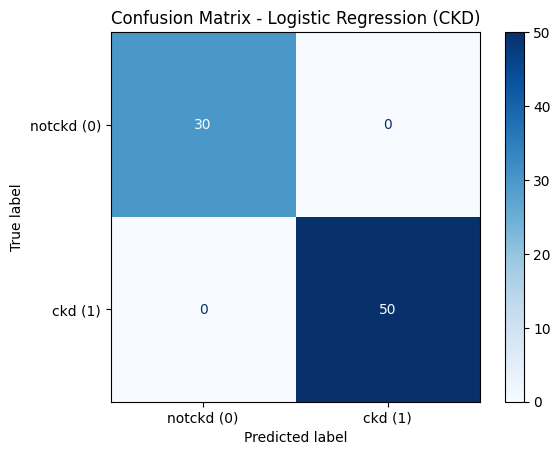

In [19]:
cm_final = confusion_matrix(y_test_encoded, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['notckd (0)', 'ckd (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (CKD)')
plt.show()

In [20]:
joblib.dump(model_lr, 'ckd_model.pkl')

['ckd_model.pkl']

In [22]:
label_mapping = {"ckd": 1, "notckd": 0}
with open('ckd_label_mapping.json', 'w') as file_json:
    json.dump(label_mapping, file_json, indent=4)

print("Model dan label mapping berhasil disimpan.")

Model dan label mapping berhasil disimpan.


In [23]:
pipeline = joblib.load('ckd_model.pkl')
data_pasien_baru = {
    'age': 45,
    'bp': 80,
    'sg': 1.02,
    'al': 1,
    'su': 0,
    'rbc': 'normal',
    'pc': 'normal',
    'pcc': 'notpresent',
    'ba': 'notpresent',
    'bgr': 120,
    'bu' : 36,
    'sc' : 0.8,
    'sod': 104,
    'pot' : 2.5,
    'hemo': 14.5,
    'pcv' : 38,
    'wc' : 6000,
    'rc' : 3.8,
    'htn' : 'no',
    'dm' : 'yes',
    'cad' : 'no',
    'appet': 'good',
    'pe': 'no',
    'ane': 'no'
    

}

# bungkus jadi DataFrame 1 baris — coba isi sendiri
df_pasien_baru = pd.DataFrame([data_pasien_baru])

# predict
prediksi_angka = pipeline.predict(df_pasien_baru)
print("Prediksi (angka):", prediksi_angka)

Prediksi (angka): [1]


In [24]:
reverse_label_mapping = {v: k for k, v in label_mapping.items()} # Contoh melihat hasilnya print("Mapping awal :", label_mapping) print("Mapping balik:", reverse_label_mapping)

In [25]:
# prediksi_angka berbentuk array (misal [1]), ambil elemen pertamanya saja
hasil_label = reverse_label_mapping[prediksi_angka[0]]
print("Hasil prediksi:", hasil_label)

Hasil prediksi: ckd


In [26]:
# predict_proba mengembalikan probabilitas untuk KEDUA kelas dalam 1 array,
# formatnya: [[prob_kelas_0, prob_kelas_1]]
prediksi_proba = pipeline.predict_proba(df_pasien_baru)
print("Probabilitas:", prediksi_proba)

Probabilitas: [[0.01040724 0.98959276]]


In [27]:
prob_ckd = prediksi_proba[0][1]
print(f"Probabilitas CKD: {prob_ckd:.2%}")

Probabilitas CKD: 98.96%
